# Importamos bibliotecas necesarias

In [7]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import models, transforms, datasets
import time
import gc
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import seaborn as sns
from PIL import Image

en este bloque se definen las transformaciones para el preprocesamiento de las imágenes.

#puedes descargar el dataset en:
https://www.kaggle.com/datasets/puneet6060/intel-image-classification

In [ ]:
# 1. Configuración y Dimensiones
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),     # Agrega un poco de aleatoriedad para mejorar la generalización
    transforms.RandomRotation(10),         # Agrega un poco de aleatoriedad para mejorar la generalización
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

En este bloque se cargan los datasets de entrenamiento y prueba haciendo uso de la clase ImageFolder de torchvision. También se usa DataLoader para el proceso de evaluación y entrenamiento.

In [ ]:
# Cargar datasets
train_dataset = datasets.ImageFolder('archive (1)\\seg_train\\seg_train', transform=transform)      #Agrega la dirección correcta de tu dataset de entrenamiento
test_dataset = datasets.ImageFolder('archive (1)\\seg_test\\seg_test', transform=test_transform)    #Agrega la dirección correcta de tu dataset de prueba

train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=32, shuffle=False)

# Obtener dimensiones de la base
print(f"Número de imágenes de entrenamiento: {len(train_dataset)}")
print(f"Número de imágenes de prueba: {len(test_dataset)}")
print(f"Clases detectadas: {train_dataset.classes}")

Número de imágenes de entrenamiento: 14034
Número de imágenes de prueba: 3000
Clases detectadas: ['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']


En este bloque se carga la arquitectura del modelo preentrenado GoogLeNet y se adapta su capa de clasificación totalmente conectada (fully connected) para que coincida con el número de clases de nuestro dataset. Posteriormente, el modelo se transfiere al dispositivo seleccionado (CPU o GPU) para su procesamiento. 

Asimismo, se definen la función de pérdida mediante Entropía Cruzada y el optimizador Adam con una tasa de aprendizaje (learning rate) configurada en 0.0001 para el proceso de optimización de los parámetros del modelo.

In [ ]:
# Cargar GoogLeNet
model = models.googlenet(weights='DEFAULT')
model.fc = nn.Linear(model.fc.in_features, len(train_dataset.classes))
model = model.to(device)

# Función de pérdida y Optimizador
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.0001)

En este bloque se define e implementa la función `train_model` para ejecutar el bucle de entrenamiento por épocas. Para cada lote (batch) de datos, el modelo se configura en modo de entrenamiento (`.train()`), calcula la predicción (forward), obtiene la pérdida y actualiza los pesos mediante retropropagación.

Al final de cada época, se calculan y guardan las métricas de pérdida y precisión (accuracy). Finalmente, se incluye una limpieza explícita de memoria con `gc.collect()` y se almacena localmente el estado del modelo (`.state_dict()`) cada vez que se supera la mejor precisión registrada.

In [11]:
history_losses = []
history_accuracies = []
def train_model(model, criterion, optimizer, num_epochs=12):
    best_acc = 0.0
    for epoch in range(num_epochs):
        model.train()
        running_loss = 0.0
        correct = 0
        total = 0
        
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            
            # Forward
            outputs = model(images)
            loss = criterion(outputs, labels)
            
            # Backward y optimización
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            
            running_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
            
        epoch_acc = 100 * correct / total
        print(f'Época [{epoch+1}/{num_epochs}] - Pérdida: {running_loss/len(train_loader):.4f} - Precisión: {epoch_acc:.2f}%')

        history_losses.append(running_loss/len(train_loader))
        history_accuracies.append(epoch_acc)

        # Forzar limpieza de memoria en cada época para evitar acumulación de objetos no utilizados
        gc.collect()

        if epoch_acc > best_acc:
            best_acc = epoch_acc
            torch.save(model.state_dict(), 'mejor_modelo_googlenet.pth')
            print(f"-->  Modelo guardado con {best_acc:.2f}%")

# Ejecutar entrenamiento
train_model(model, criterion, optimizer, num_epochs=12)

Época [1/12] - Pérdida: 0.3757 - Precisión: 87.95%
-->  Modelo guardado con 87.95%
Época [2/12] - Pérdida: 0.2060 - Precisión: 92.94%
-->  Modelo guardado con 92.94%
Época [3/12] - Pérdida: 0.1621 - Precisión: 94.46%
-->  Modelo guardado con 94.46%
Época [4/12] - Pérdida: 0.1322 - Precisión: 95.73%
-->  Modelo guardado con 95.73%
Época [5/12] - Pérdida: 0.1085 - Precisión: 96.30%
-->  Modelo guardado con 96.30%
Época [6/12] - Pérdida: 0.0893 - Precisión: 97.05%
-->  Modelo guardado con 97.05%
Época [7/12] - Pérdida: 0.0786 - Precisión: 97.31%
-->  Modelo guardado con 97.31%
Época [8/12] - Pérdida: 0.0628 - Precisión: 97.68%
-->  Modelo guardado con 97.68%
Época [9/12] - Pérdida: 0.0498 - Precisión: 98.23%
-->  Modelo guardado con 98.23%
Época [10/12] - Pérdida: 0.0420 - Precisión: 98.77%
-->  Modelo guardado con 98.77%
Época [11/12] - Pérdida: 0.0436 - Precisión: 98.52%
Época [12/12] - Pérdida: 0.0455 - Precisión: 98.36%


En este bloque se define y ejecuta la función `evaluate_model` para medir el rendimiento final del sistema. El código carga los mejores pesos guardados (`.load_state_dict()`), configura la red en modo de evaluación (`.eval()`) y desactiva el cálculo de gradientes con `torch.no_grad()` para optimizar la memoria. Finalmente, recorre el cargador de datos para procesar las imágenes del set de prueba y calcular el porcentaje total de precisión (accuracy).

In [12]:
def evaluate_model(model, loader, path='mejor_modelo_googlenet.pth'):
    model.load_state_dict(torch.load(path))
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
            
    print(f'Precisión final en el set de prueba: {100 * correct / total:.2f}%')

evaluate_model(model, test_loader)

Precisión final en el set de prueba: 92.60%


En este bloque se define y ejecuta la función `plot_training_progress` utilizando Matplotlib para visualizar la evolución del modelo. El código limpia cualquier figura previa y genera dos gráficos lineales en paralelo (subplots): uno para el progreso de la pérdida (loss) y otro para el porcentaje de precisión (accuracy) a lo largo de las épocas.

Gráfico de progreso del entrenamiento:


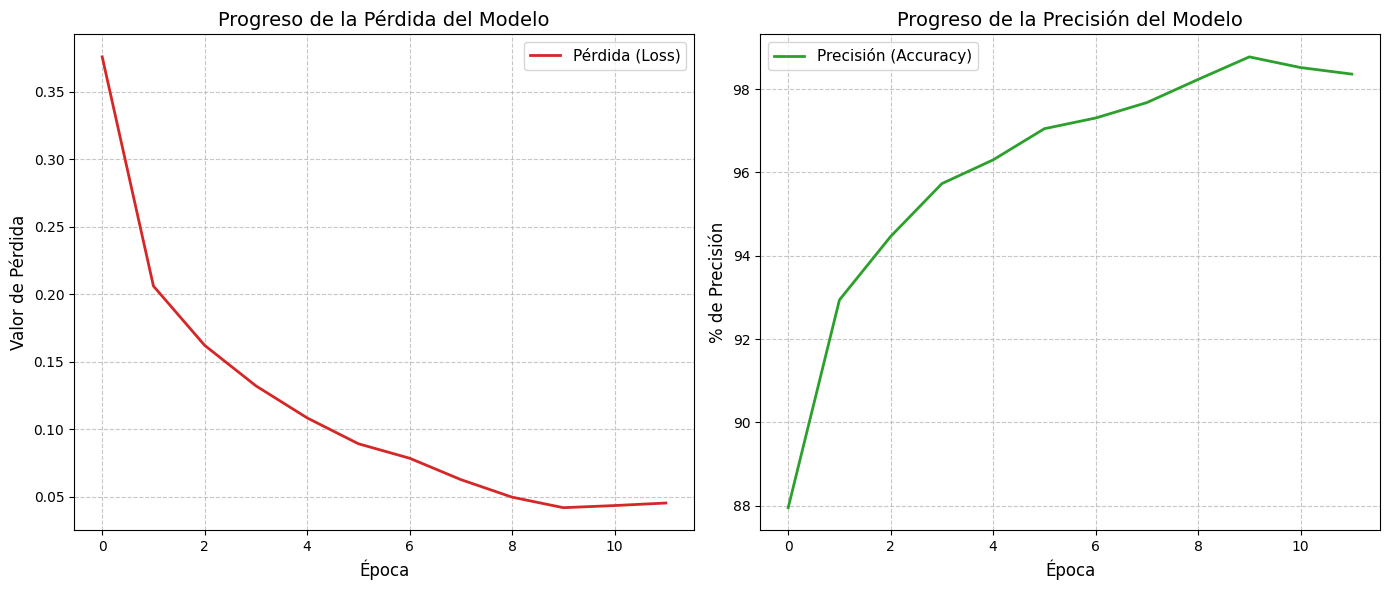

In [ ]:
def plot_training_progress(train_losses, train_accuracies):
    """Genera gráficos de la pérdida y precisión durante el entrenamiento."""
    # Forzar limpieza de figuras anteriores
    plt.close('all') 
    
    plt.figure(figsize=(14, 6))
    
    # Gráfico de Pérdida (Loss)
    plt.subplot(1, 2, 1)
    plt.plot(train_losses, label='Pérdida (Loss)', color='tab:red', linewidth=2)
    plt.title('Progreso de la Pérdida del Modelo', fontsize=14)
    plt.xlabel('Época', fontsize=12)
    plt.ylabel('Valor de Pérdida', fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.legend(fontsize=11)
    
    # Gráfico de Precisión (Accuracy)
    plt.subplot(1, 2, 2)
    plt.plot(train_accuracies, label='Precisión (Accuracy)', color='tab:green', linewidth=2)
    plt.title('Progreso de la Precisión del Modelo', fontsize=14)
    plt.xlabel('Época', fontsize=12)
    plt.ylabel('% de Precisión', fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.legend(fontsize=11)
    
    plt.tight_layout()
    plt.show() # Mostrar gráfico
    gc.collect()


if 'history_losses' in locals() and history_losses:
    #Gráfico de progreso 
    print("Gráfico de progreso del entrenamiento:")
    plot_training_progress(history_losses, history_accuracies)

En este bloque se crea un `DataLoader` aleatorio y se ejecuta la función `visualize_predictions_grid` para evaluar visualmente el modelo en el set de prueba. Cada subgráfico resalta en verde los aciertos y en rojo los errores, mostrando la etiqueta real frente a la predicha.

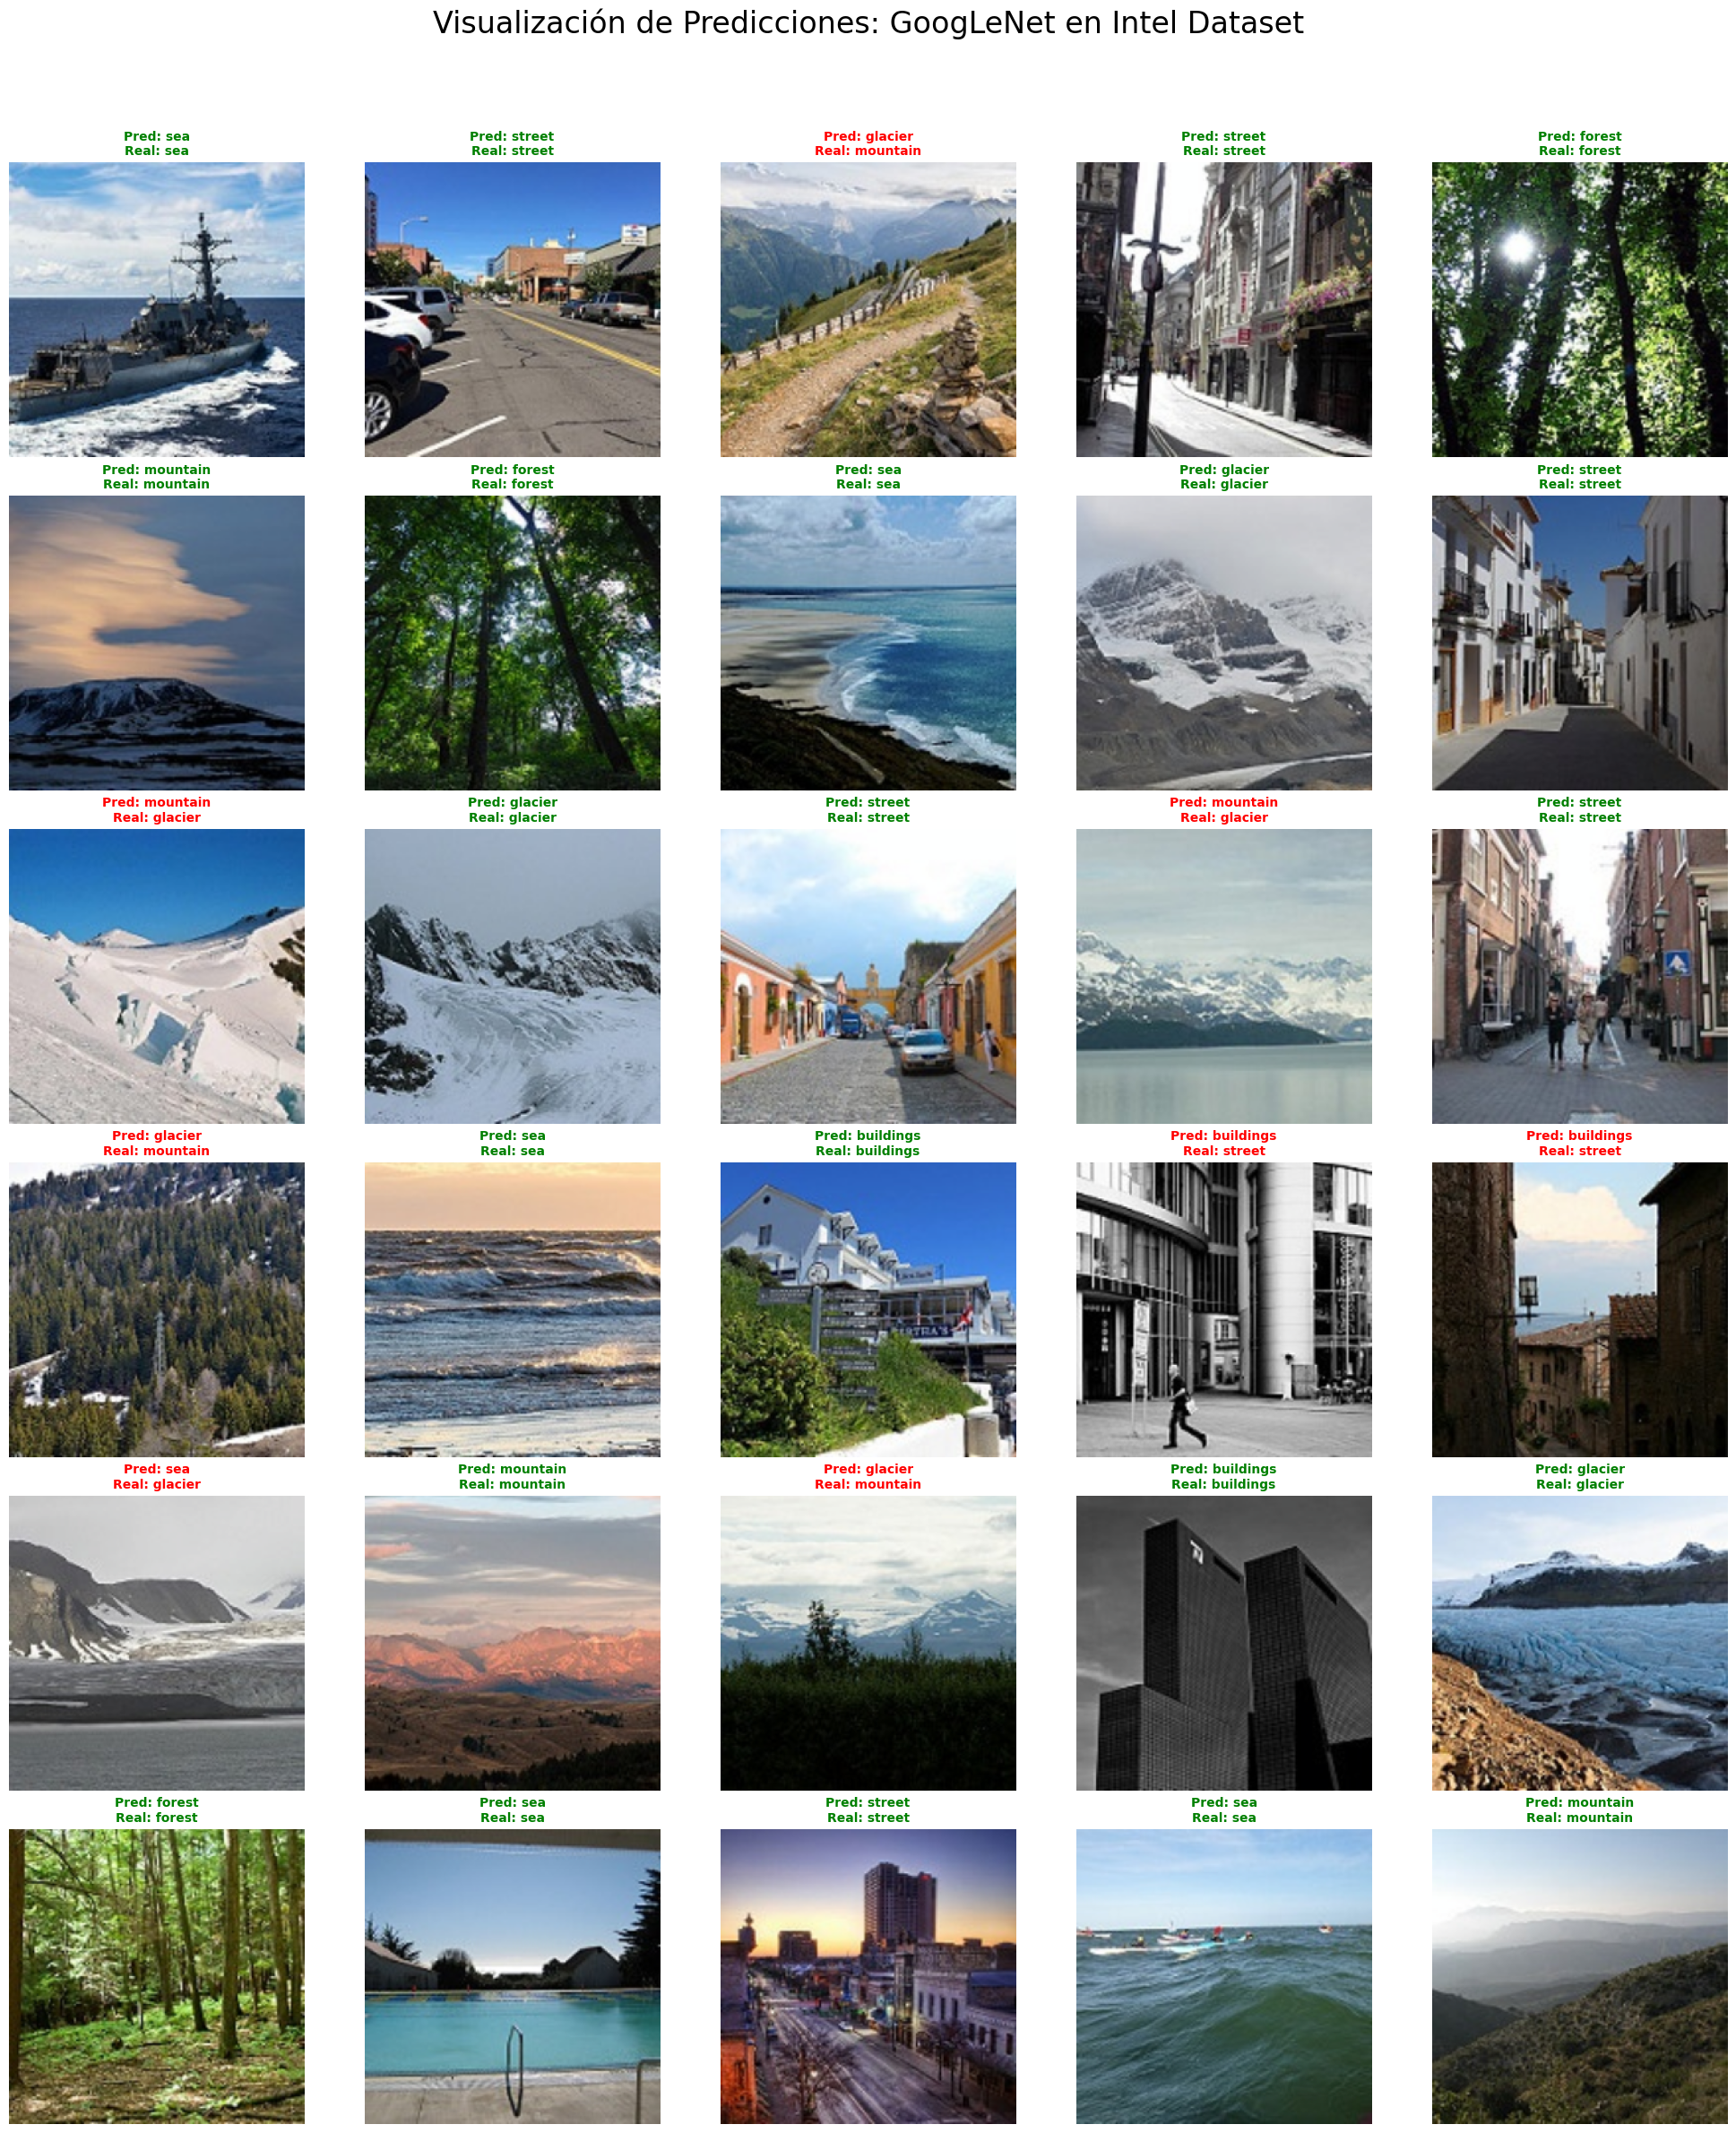

In [ ]:
test_loader_random = torch.utils.data.DataLoader(test_dataset, batch_size=32, shuffle=True)

def visualize_predictions_grid(model, loader, classes, num_images=30):
    """Muestra un grid de imágenes con la etiqueta real vs. la predicha."""
    plt.close('all') # Limpiar figuras
    model.eval()
    
    # Obtener un batch de imágenes y etiquetas
    images, labels = next(iter(loader))
    
    # Tomar solo num_images (en nuestro caso 30 para mostrar un grid 5x6)
    images = images[:num_images]
    labels = labels[:num_images]
    
    # Predicciones
    with torch.no_grad():
        images_device = images.to(device)
        outputs = model(images_device)
        _, preds = torch.max(outputs, 1)
        preds = preds.cpu() # Volver a CPU para graficar

    # Crear el grid de Matplotlib (6 filas x 5 columnas)
    fig, axes = plt.subplots(6, 5, figsize=(20, 25))
    fig.suptitle('Visualización de Predicciones: GoogLeNet en Intel Dataset', fontsize=24)
    
    # Aplanar axes para iterar fácilmente (6x5 = 30 axes)
    axes_flat = axes.flatten()

    for i in range(num_images):
        ax = axes_flat[i]
        
        # Deshacer la normalización para mostrar la imagen correctamente
        image_np = images[i].numpy().transpose((1, 2, 0)) # CHW a HWC
        mean = np.array([0.485, 0.456, 0.406])
        std = np.array([0.229, 0.224, 0.225])
        image_np = std * image_np + mean
        image_np = np.clip(image_np, 0, 1) # Asegurar rango 0-1
        
        ax.imshow(image_np)
        
        # Obtener nombres de etiquetas
        pred_label = classes[preds[i]]
        true_label = classes[labels[i]]
        
        # Cambiar color de título si la predicción es correcta (verde) o incorrecta (rojo)
        title_color = 'green' if preds[i] == labels[i] else 'red'
        
        ax.set_title(f"Pred: {pred_label}\nReal: {true_label}", color=title_color, fontsize=10, fontweight='bold')
        ax.axis('off') # Ocultar ejes
    
    plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Ajustar para que el título no se superponga
    plt.show()
    gc.collect()

# Visualizar predicciones 
visualize_predictions_grid(model, test_loader_random, train_dataset.classes)